# Проверка bbox-экзамена через review pool

1. читаем assignments из `review_pool`;
2. читаем маппинг `review_task_id -> bbox_assignment_id`;
3. считаем majority vote по каждому bbox assignment;
4. считаем долю верно выполненных bbox-задач для каждого исполнителя;
5. подготавливаем таблицу со значением навыка от `0` до `100`.

In [1]:
import json
import os
import sys
import types
from collections import Counter, defaultdict
from pathlib import Path
from importlib.metadata import version

from dotenv import load_dotenv

import cattr
import httpx._types as httpx_types

if not hasattr(httpx_types, "VerifyTypes"):
    httpx_types.VerifyTypes = bool | str | Path

if "pkg_resources" not in sys.modules:
    pkg_resources = types.ModuleType("pkg_resources")

    class _Distribution:
        def __init__(self, package_name: str):
            self.version = version(package_name)

    pkg_resources.get_distribution = _Distribution
    sys.modules["pkg_resources"] = pkg_resources

if not hasattr(cattr.converters.BaseConverter, "_unstructure_enum"):
    def _unstructure_enum(self, obj):
        return obj.value

    cattr.converters.BaseConverter._unstructure_enum = _unstructure_enum

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))

import matplotlib.pyplot as plt
import pandas as pd
import toloka.client as toloka


In [2]:
load_dotenv()

TOKEN = os.getenv("TOLOKA_TOKEN")
TOLOKA_API_URL = "https://tasks.yandex.ru"

current_dir = Path.cwd()
tasks_dir = current_dir
toloka_client = toloka.TolokaClient(TOKEN, url=TOLOKA_API_URL)

review_pool_id = "6124122"
mapping_path = tasks_dir / f"bbox_to_review_mapping_{review_pool_id}.json"
verdict_ok_values = {"good", "abscence"}

bbox_results_path = tasks_dir / f"bbox_exam_majority_vote_{review_pool_id}.json"
worker_scores_path = tasks_dir / f"bbox_exam_worker_scores_{review_pool_id}.csv"
distribution_plot_path = tasks_dir / f"bbox_exam_skill_distribution_{review_pool_id}.png"


In [3]:

bbox_skill_id = ""


## Загрузка маппинга и review assignments

In [4]:
with mapping_path.open(encoding="utf-8") as file:
    bbox_to_review_mapping = json.load(file)

review_assignments = list(toloka_client.get_assignments(pool_id=review_pool_id))
assignment_statuses = Counter(str(getattr(assignment, "status", None)) for assignment in review_assignments)

print("mapping rows:", len(bbox_to_review_mapping))
print("review assignments:", len(review_assignments))
print("assignment statuses:", dict(assignment_statuses))


FileNotFoundError: [Errno 2] No such file or directory: '/Users/mvsevolod/projects/aiconf-butterflies/3-tasks/bbox_to_review_mapping_6124122.json'

## Сбор review verdicts по каждой review task

In [ ]:
review_task_to_bbox = {row["review_task_id"]: row for row in bbox_to_review_mapping}
review_votes = defaultdict(list)

for assignment in review_assignments:
    tasks = assignment.tasks or []
    solutions = assignment.solutions or []

    for task, solution in zip(tasks, solutions):
        review_task_id = getattr(task, "origin_task_id", None) or getattr(task, "id", None)
        if not review_task_id:
            continue

        review_task_id = str(review_task_id)
        if review_task_id not in review_task_to_bbox:
            continue

        output_values = solution.output_values or {}
        verdict = output_values.get("result")
        if not verdict:
            continue

        review_votes[review_task_id].append(
            {
                "assignment_id": assignment.id,
                "reviewer_id": assignment.user_id,
                "verdict": verdict,
            }
        )

print("review tasks with votes:", len(review_votes))


review tasks with votes: 1000


## Подсчет результата по bbox assignment
Считаем bbox assignment правильным только в двух случаях:
1. Все три review-вердикта равны `good`.
2. Все три review-вердикта равны `abscence` и в исходном `guides` действительно нет рамок.
Во всех остальных случаях bbox assignment считается неправильным.


In [ ]:
review_task_inputs = {}

for assignment in review_assignments:
    tasks = assignment.tasks or []

    for task in tasks:
        review_task_id = getattr(task, "origin_task_id", None) or getattr(task, "id", None)
        if not review_task_id:
            continue

        review_task_id = str(review_task_id)
        if review_task_id not in review_task_to_bbox:
            continue

        if review_task_id not in review_task_inputs:
            review_task_inputs[review_task_id] = task.input_values or {}

bbox_results = []

for review_task_id, mapping_row in review_task_to_bbox.items():
    votes = review_votes.get(review_task_id, [])
    verdicts = [vote["verdict"] for vote in votes]
    verdict_counter = Counter(verdicts)

    input_values = review_task_inputs.get(review_task_id, {})
    guides = input_values.get("guides") or []
    has_guides = len(guides) > 0

    all_good = len(verdicts) == 3 and set(verdicts) == {"good"}
    all_abscence_and_empty = len(verdicts) == 3 and set(verdicts) == {"abscence"} and not has_guides
    is_correct = all_good or all_abscence_and_empty

    bbox_results.append(
        {
            "review_task_id": review_task_id,
            "bbox_assignment_id": mapping_row["bbox_assignment_id"],
            "bbox_worker_id": mapping_row["bbox_worker_id"],
            "votes_count": len(votes),
            "all_verdicts": verdicts,
            "verdict_counts": dict(verdict_counter),
            "has_guides": has_guides,
            "is_correct": is_correct,
            "is_all_good": all_good,
            "is_all_abscence_and_empty": all_abscence_and_empty,
        }
    )

bbox_results_df = pd.DataFrame(bbox_results).sort_values(["bbox_worker_id", "bbox_assignment_id", "review_task_id"]).reset_index(drop=True)
print("bbox tasks total:", len(bbox_results_df))
print("bbox tasks with at least one vote:", int((bbox_results_df["votes_count"] > 0).sum()))
bbox_results_df.head()


bbox tasks total: 1000
bbox tasks with at least one vote: 1000


,review_task_id,bbox_assignment_id,bbox_worker_id,votes_count,all_verdicts,verdict_counts,has_guides,is_correct,is_all_good,is_all_abscence_and_empty
0,00005d725a--69e4c244bd92971e5f576786,00005d7002--69e4a1aa7c58cc18c0ebfc45,06e329f158c91dafb06bdff2c415c870,3,"[good, bad, good]","{'good': 2, 'bad': 1}",True,False,False,False
1,00005d725a--69e4c244bd92971e5f57678a,00005d7002--69e4a1aa7c58cc18c0ebfc45,06e329f158c91dafb06bdff2c415c870,3,"[good, good, good]",{'good': 3},True,True,True,False
2,00005d725a--69e4c244bd92971e5f57678e,00005d7002--69e4a1aa7c58cc18c0ebfc45,06e329f158c91dafb06bdff2c415c870,3,"[good, good, bad]","{'good': 2, 'bad': 1}",True,False,False,False
3,00005d725a--69e4c244bd92971e5f576792,00005d7002--69e4a1aa7c58cc18c0ebfc45,06e329f158c91dafb06bdff2c415c870,3,"[good, bad, bad]","{'good': 1, 'bad': 2}",False,False,False,False
4,00005d725a--69e4c244bd92971e5f576796,00005d7002--69e4a1aa7c58cc18c0ebfc45,06e329f158c91dafb06bdff2c415c870,3,"[good, good, good]",{'good': 3},True,True,True,False


## Подсчет навыка исполнителей
Для каждого bbox-исполнителя считаем долю правильных заданий из всех его 10 bbox assignments и переводим её в шкалу от 0 до 100.


In [ ]:
worker_rows = []

for bbox_worker_id, group in bbox_results_df.groupby("bbox_worker_id"):
    total_tasks = len(group)
    reviewed_tasks = int((group["votes_count"] > 0).sum())
    correct_tasks = int(group["is_correct"].sum())
    skill_value = round(100 * correct_tasks / total_tasks) if total_tasks else 0

    worker_rows.append(
        {
            "bbox_worker_id": bbox_worker_id,
            "total_tasks": total_tasks,
            "reviewed_tasks": reviewed_tasks,
            "correct_tasks": correct_tasks,
            "skill_value": skill_value,
        }
    )

worker_scores_df = pd.DataFrame(worker_rows).sort_values(
    ["skill_value", "correct_tasks", "reviewed_tasks"],
    ascending=[False, False, False],
).reset_index(drop=True)

print("workers scored:", len(worker_scores_df))
print(worker_scores_df["skill_value"].describe())
worker_scores_df


workers scored: 100
count    100.000000
mean      34.700000
std       17.835103
min        0.000000
25%       27.500000
50%       40.000000
75%       50.000000
max       60.000000
Name: skill_value, dtype: float64


,bbox_worker_id,total_tasks,reviewed_tasks,correct_tasks,skill_value
0,0f24d3a87c8c0a48f347c1f8d0a9b726,10,10,6,60
1,20d205186e3196926ffece3997c36c78,10,10,6,60
2,24d2aafca2fd49676c045fab7d351db6,10,10,6,60
3,3032f9fcf41b8d2886736d4e7b14edae,10,10,6,60
4,33273fc33b2cda0625d5c0c52e3f7f33,10,10,6,60
...,...,...,...,...,...
95,9c236f17a49658cf7caa0fad510421ab,10,10,0,0
96,aa23658d95c52fc29caa918edc4dcd91,10,10,0,0
97,c59a518922e45e3d2fa28c11793cffd7,10,10,0,0
98,c79879f38641bacbc6d89359af043a0b,10,10,0,0


## Сохранение результатов

In [ ]:
bbox_results_df.to_json(bbox_results_path, orient="records", force_ascii=False, indent=2)
worker_scores_df.to_csv(worker_scores_path, index=False)

print("saved:", bbox_results_path)
print("saved:", worker_scores_path)


saved: /Users/mvsevolod/projects/aiconf-butterflies-segmentation/tasks/bbox_exam_majority_vote_6124122.json
saved: /Users/mvsevolod/projects/aiconf-butterflies-segmentation/tasks/bbox_exam_worker_scores_6124122.csv


## Распределение навыков
Показываем столбики по точным значениям `skill_value`, чтобы распределение читалось лучше.


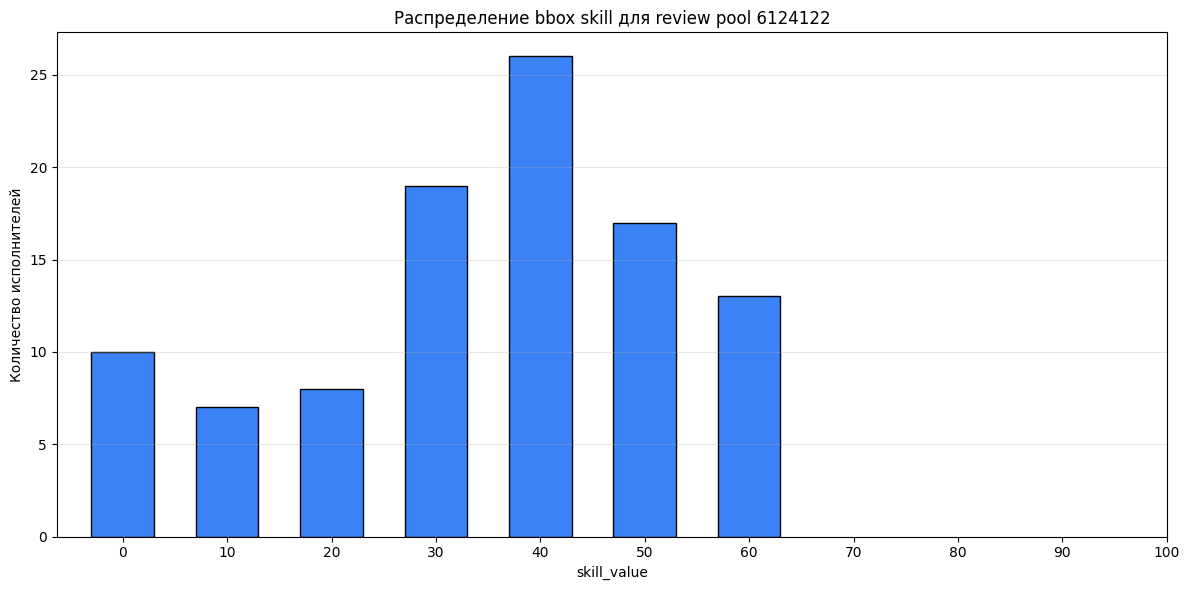

saved: /Users/mvsevolod/projects/aiconf-butterflies-segmentation/tasks/bbox_exam_skill_distribution_6124122.png


In [ ]:
distribution_df = worker_scores_df["skill_value"].value_counts().sort_index().reset_index()
distribution_df.columns = ["skill_value", "workers_count"]
distribution_df

plt.figure(figsize=(12, 6))
plt.bar(distribution_df["skill_value"], distribution_df["workers_count"], width=6, color="#3b82f6", edgecolor="black")
plt.title(f"Распределение bbox skill для review pool {review_pool_id}")
plt.xlabel("skill_value")
plt.ylabel("Количество исполнителей")
plt.xticks(range(0, 101, 10))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(distribution_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("saved:", distribution_plot_path)


## Присвоение bbox skill
Выбираем исполнителей со `skill_value == 60` и выставляем им bbox skill со значением `60`.


In [ ]:
bbox_skill_id = "16287"

workers_to_update = worker_scores_df.loc[
    worker_scores_df["skill_value"] == 60,
    ["bbox_worker_id", "skill_value"],
].copy()

print("workers to update:", len(workers_to_update))
workers_to_update

from decimal import Decimal

for row in workers_to_update.itertuples(index=False):
    toloka_client.set_user_skill(
        skill_id=bbox_skill_id,
        user_id=row.bbox_worker_id,
        value=Decimal("60"),
    )

workers to update: 13
